## Name : Sulaiman Alfawzan

# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [ ]:
# pd.read_csv("../../../datasets/bmi_and_life_expectancy.csv").head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


In [3]:
from pathlib import Path

DATA_PATH = Path('./Data/bmi_and_life_expectancy.csv')
print(DATA_PATH.resolve())
print(DATA_PATH.exists())
df = pd.read_csv(DATA_PATH)
df.head()


C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C3\M1\Data\bmi_and_life_expectancy.csv
True


,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
x = df['BMI'].values
y = df['Life expectancy'].values

### Step 2.b print the type of each

In [5]:
type(x), type(y)

(numpy.ndarray, numpy.ndarray)

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
# Both of y and x are numerical variables.
# Since the target y is numerical  this is a regression.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (163,)
y shape: (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
df[['BMI', 'Life expectancy']].agg(['min', 'max','median','mean', 'std'])

,BMI,Life expectancy
min,19.866920,44.500000
max,30.995630,84.600000
median,25.320540,71.800000
mean,24.792378,69.666933
std,2.427900,8.981933


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'BMI vs Life expectancy')

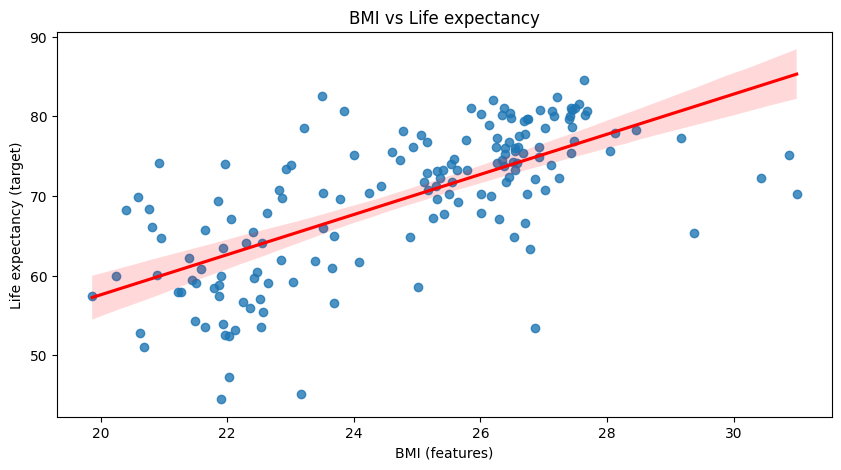

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.regplot(x='BMI', y='Life expectancy', data=df, line_kws={'color':'red'})
plt.xlabel('BMI (features)')
plt.ylabel('Life expectancy (target)')
plt.title('BMI vs Life expectancy')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [15]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(df['BMI'], df['Life expectancy'])
print("its incerasing by",r_value**2)

its incerasing by 0.4634455864661574


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


model_Linear = LinearRegression()

polynomial_expansion  = PolynomialFeatures(
    degree=3, 
    include_bias=False
    )

polynomial_regression = make_pipeline(
    polynomial_expansion,
    LinearRegression(),
)

### Step 8. Split the dataset into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X = x.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

### Step 9. Train both models on the training set

### Step 10. Evaluate and compare which of the two models score better on the `train` set

### Step 11. Evaluate and compare which of the two models score better on the `test` set